In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as Imbpipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, r2_score, classification_report

(20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
           longitude      latitude  housing_median_age   total_rooms  \
count   20640.000000  20640.000000        20640.000000  20640.000000   
unique           NaN           NaN                 NaN           NaN   
top              N

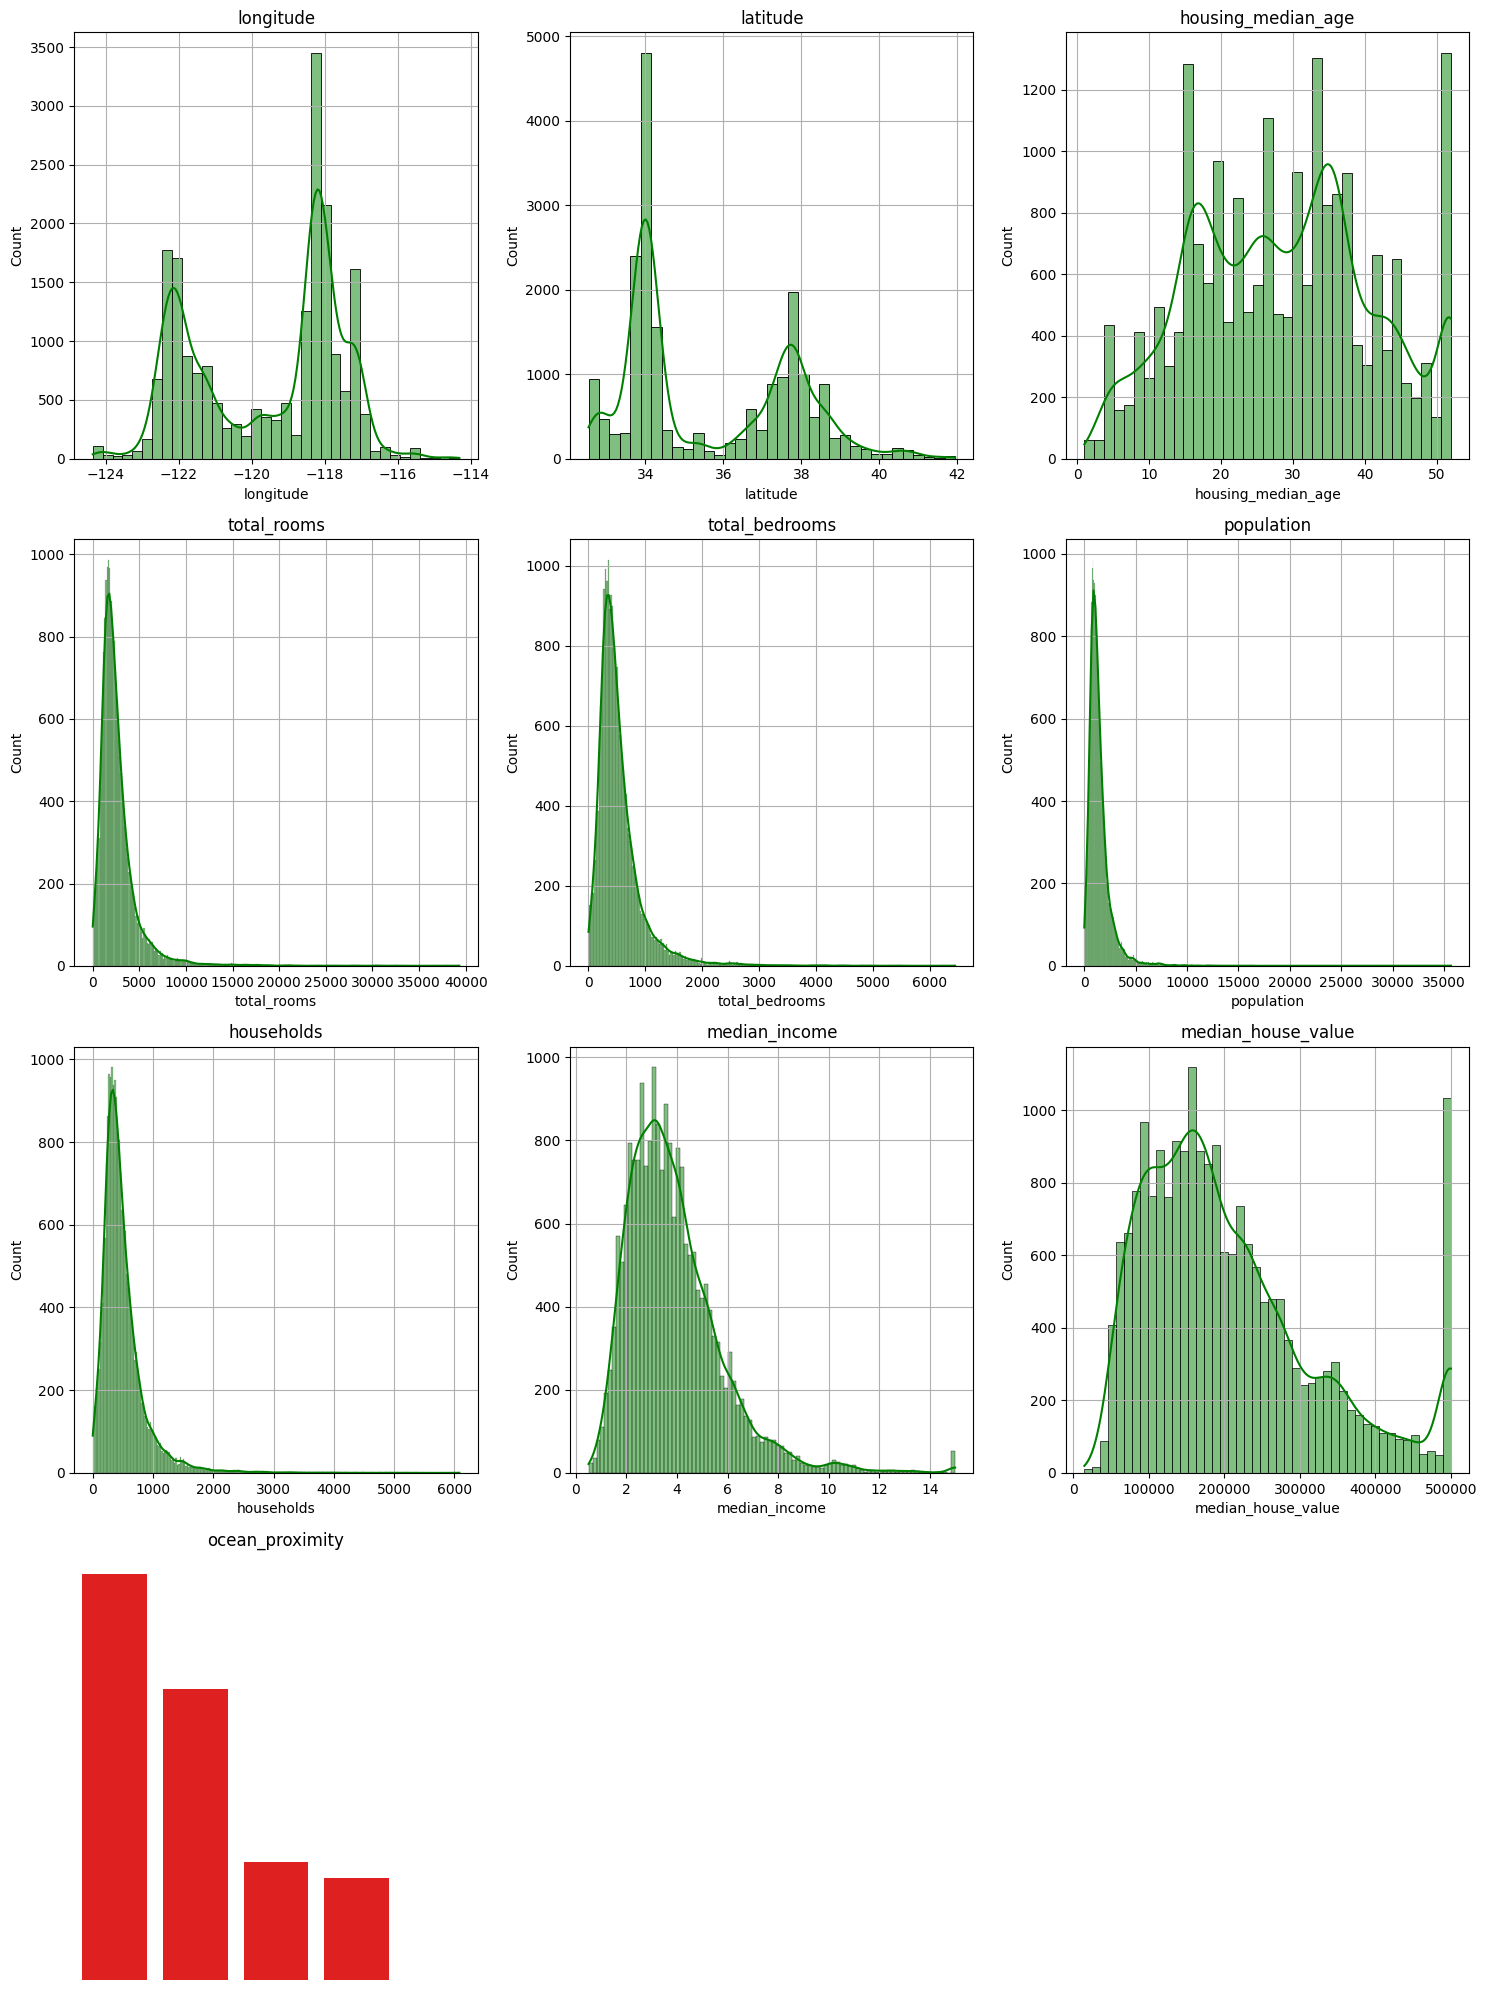

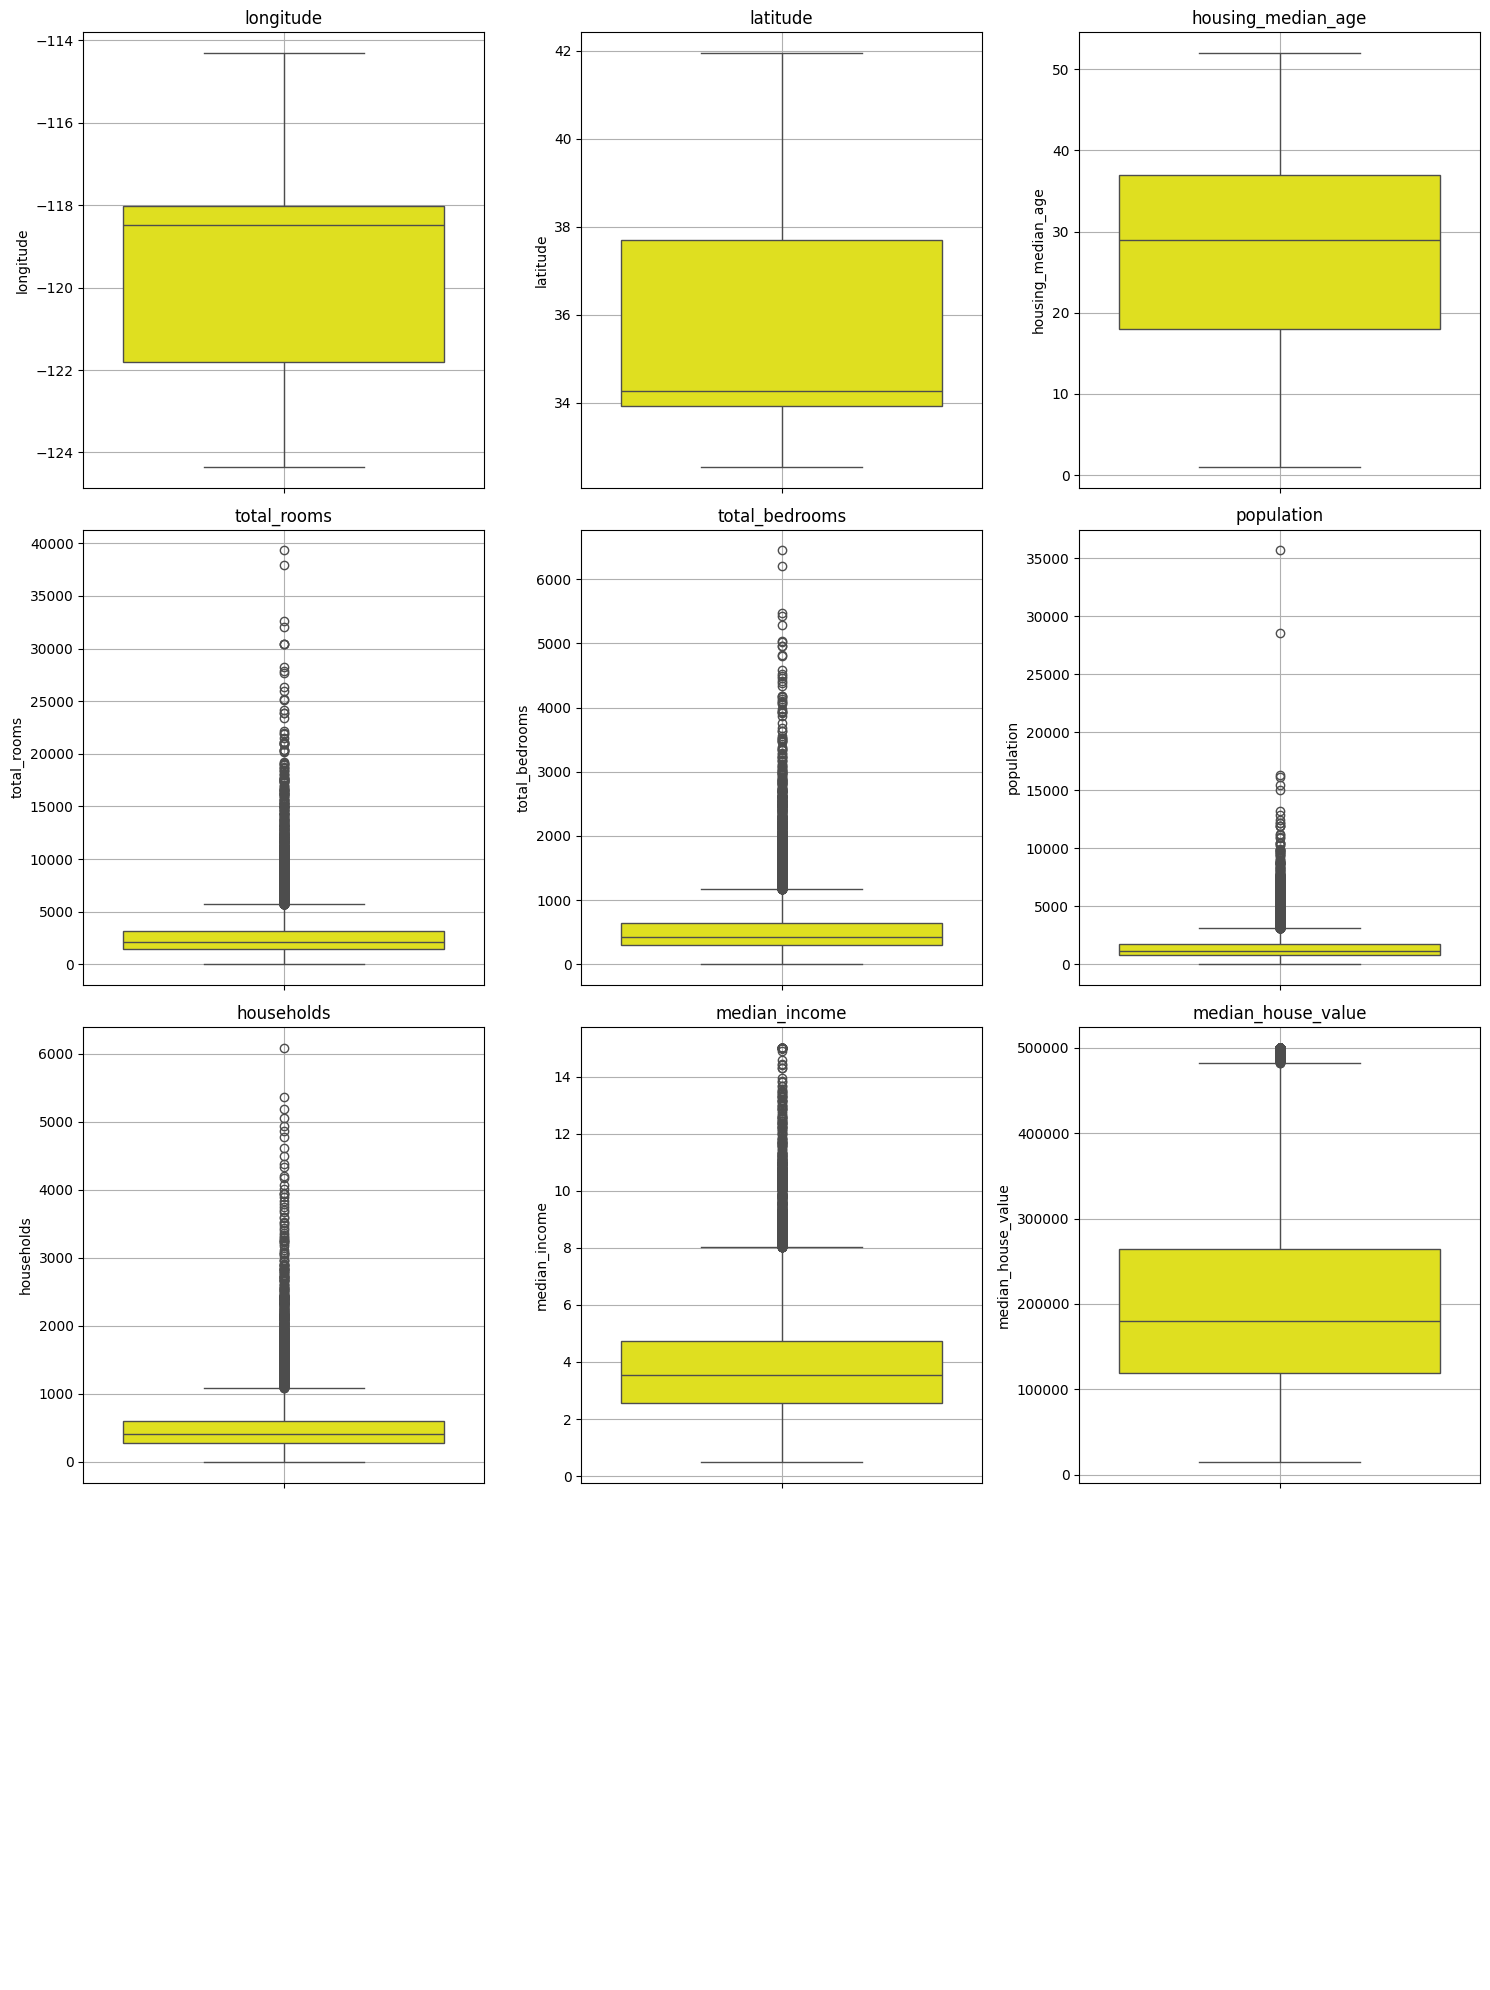

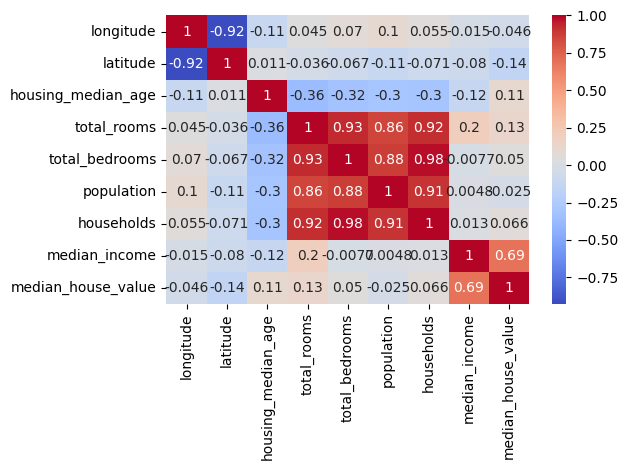

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


In [2]:
# Phase 1(Exploratory Data Analysis)
df = pd.read_csv(r'/content/drive/MyDrive/housing.csv') # reading the csv file

print(df.shape)
print(df.info())
print(df.describe(include='all'))
print(df.isna().sum())
print(df.duplicated().sum())

# histogram and barchart

cols = 3
rows = (len(df.columns) + cols - 1) // cols

fig1, axes1 = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes1 = axes1.flatten()


for i, feature in enumerate(df.columns):
  if np.issubdtype(df[feature].dtype, np.number):
    sns.histplot(df[feature], kde=True, color='green', ax=axes1[i])
    axes1[i].grid(True)
    axes1[i].set_title(f"{feature}")
  else:
    sns.barplot(df[feature].value_counts(), ax=axes1[i], color='red')
    axes1[i].grid(True)
    axes1[i].set_title(f"{feature}")

for i in range(len(df.columns) - 1, len(axes1)):
  axes1[i].axis('off')

plt.tight_layout()
plt.show()

# Plot boxplots to spot outliers
fig2, axes2 = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes2 = axes2.flatten()

num_cols = df.select_dtypes(include=[np.number]).columns # continuous columns

for i, feature in enumerate(num_cols):
  sns.boxplot(df[feature], color='yellow', ax=axes2[i])
  axes2[i].grid(True)
  axes2[i].set_title(f"{feature}")


for i in range(len(num_cols), len(axes2)):
  axes2[i].axis('off')


plt.tight_layout()
plt.show()


# heatmap

corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

print(df.dtypes)

In [3]:
# Phase 2(Basic Cleaning)

# Fix data types (

df = df.apply(
    lambda cols: pd.to_numeric(cols.astype(str).str.replace(r'[0-9.\-+]', '', regex=True), errors='coerce')
    if pd.to_numeric(cols.astype(str).str.replace(r'[0-9.\-+]', '', regex=True), errors='coerce').notna().mean() >= 0.5
    else cols
)

# . Handle inconsistent categories (strip, lowercase)

for feature in df.select_dtypes(exclude=[np.number]).columns:
  df[feature] = df[feature].str.strip().str.lower()

# . Drop irrelevant columns (IDs, names, columns with >50% nulls)

for feature in df.columns:
  if df[feature].isna().mean() >= 0.5:
    df = df.drop(columns=[feature])

# Remove duplicates

if df.duplicated().sum() > 0:
  df = df.drop_duplicates()

print(df['ocean_proximity'].unique()) # classes of the categorical column


['near bay' '<1h ocean' 'inland' 'near ocean' 'island']


In [4]:
# Phase 3 — Separate & Split

x = df.drop(columns=['ocean_proximity']) # features of the dataset
y = df['ocean_proximity'] # label of the dataset

y = df['ocean_proximity'].map(
    {
        'near bay':0, '<1h ocean':1, 'inland':2, 'near ocean':3, 'island':4


    }
)

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2, stratify=y)

Accuracy=0.9779554263565892

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       458
           1       0.98      0.98      0.98      1827
           2       0.99      0.99      0.99      1310
           3       0.94      0.95      0.94       532
           4       0.00      0.00      0.00         1

    accuracy                           0.98      4128
   macro avg       0.78      0.78      0.78      4128
weighted avg       0.98      0.98      0.98      4128



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

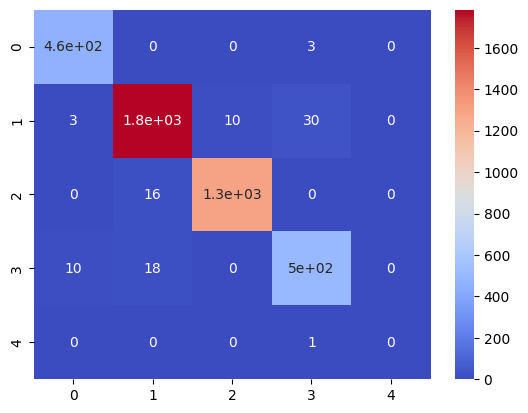

In [5]:
# Phase 4 — ML Pipeline

# . Impute missing values — mean/median for numeric, mode for categorica

num_cols = x.select_dtypes(include=[np.number]).columns # continuous features
cat_cols = x.select_dtypes(exclude=[np.number]).columns # discrete features

preprocessor = ColumnTransformer([('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                                                      ('scaler', StandardScaler())]), num_cols),

 ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder', OneHotEncoder(drop='first', sparse_output=False))]), cat_cols)])


# Pipeline

pipeline = Imbpipeline([
  ('preprocessor', preprocessor),
  ('smote', SMOTE(random_state=42, k_neighbors=2)),
  ('model', RandomForestClassifier(n_estimators=100, random_state=42))

])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

print(f"Accuracy={pipeline.score(x_test, y_test)}")
# classification report
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='coolwarm')